<a href="https://colab.research.google.com/github/Mazi-star/LAB2/blob/main/LAB2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Импортирование необходимых библиотек

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, MinMaxScaler, label_binarize
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import (precision_recall_curve, average_precision_score,
                              classification_report, confusion_matrix,
                              PrecisionRecallDisplay)


In [ ]:
file_name = '/content/wine.data.txt'
cols = ['class', 'alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash',
        'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phen',
        'proanthocyanins', 'color_intensity', 'hue', 'od280_od315', 'proline']

data = pd.read_csv(file_name, header=None, names=cols)

In [ ]:
data

,class,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phen,proanthocyanins,color_intensity,hue,od280_od315,proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   class              178 non-null    int64  
 1   alcohol            178 non-null    float64
 2   malic_acid         178 non-null    float64
 3   ash                178 non-null    float64
 4   alcalinity_of_ash  178 non-null    float64
 5   magnesium          178 non-null    int64  
 6   total_phenols      178 non-null    float64
 7   flavanoids         178 non-null    float64
 8   nonflavanoid_phen  178 non-null    float64
 9   proanthocyanins    178 non-null    float64
 10  color_intensity    178 non-null    float64
 11  hue                178 non-null    float64
 12  od280_od315        178 non-null    float64
 13  proline            178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [ ]:
print("Уникальные значения целевой колонки:", data['class'].unique())
print("Тип задачи: многоклассовая классификация (3 класса)")


Уникальные значения целевой колонки: [1 2 3]
Тип задачи: многоклассовая классификация (3 класса)


In [ ]:
print(f"Размер до удаления дубликатов: {data.shape}")
data = data.drop_duplicates()
print(f"Размер после удаления дубликатов: {data.shape}")

Размер до удаления дубликатов: (178, 14)
Размер после удаления дубликатов: (178, 14)


Баланс классов
Класс 3 содержит 48 образцов — заметно меньше, чем классы 1 (59)
и 2 (71). Данные умеренно несбалансированы.
→ Выбираем PR-кривую (Precision-Recall): она лучше отражает качество
  классификатора при дисбалансе. ROC-кривая может давать завышенные
  оценки на несбалансированных классах

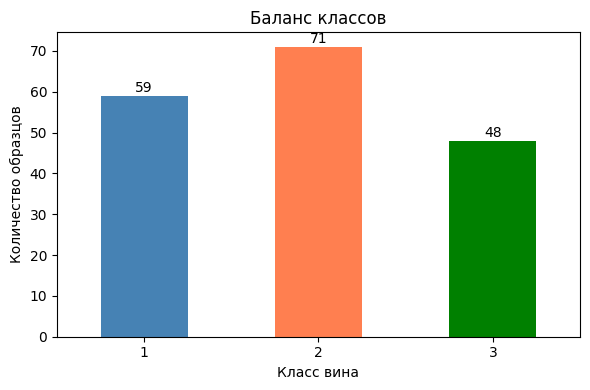

class
1    59
2    71
3    48
Name: count, dtype: int64


In [ ]:
counts = data['class'].value_counts().sort_index()

plt.figure(figsize=(6, 4))
counts.plot(kind='bar', color=['steelblue', 'coral', 'green'])
plt.title('Баланс классов')
plt.xlabel('Класс вина')
plt.ylabel('Количество образцов')
plt.xticks(rotation=0)
for i, v in enumerate(counts):
    plt.text(i, v + 1, str(v), ha='center')
plt.tight_layout()
plt.show()

print(counts)


Удаление выбросов

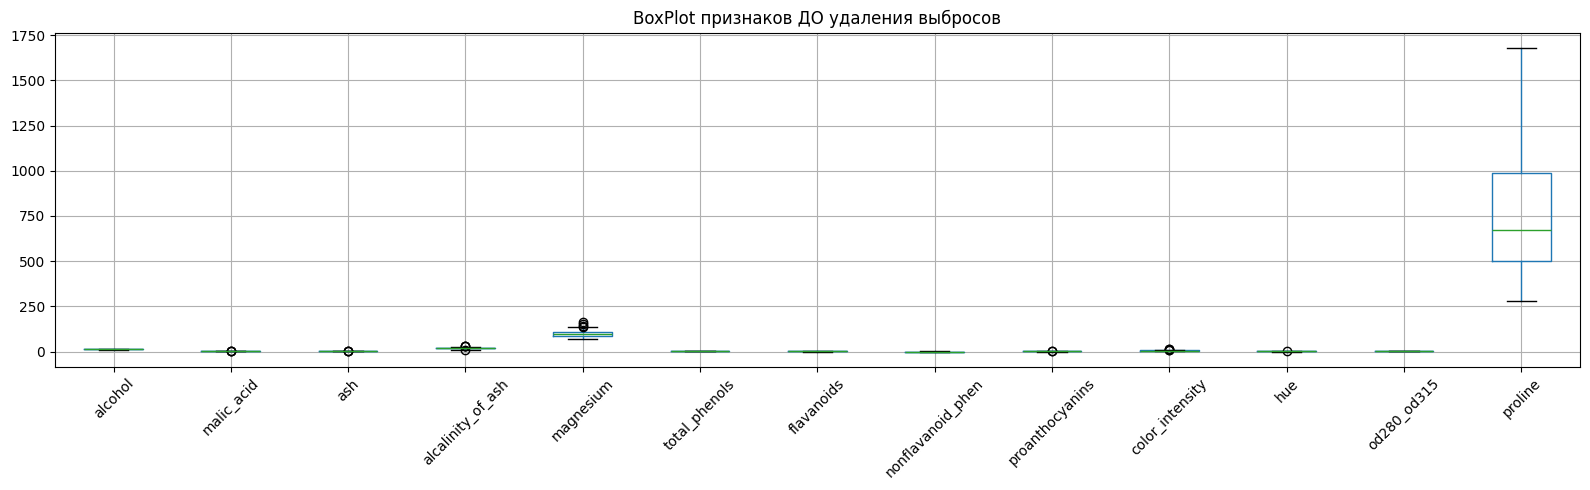

Размер после удаления выбросов: (161, 14)


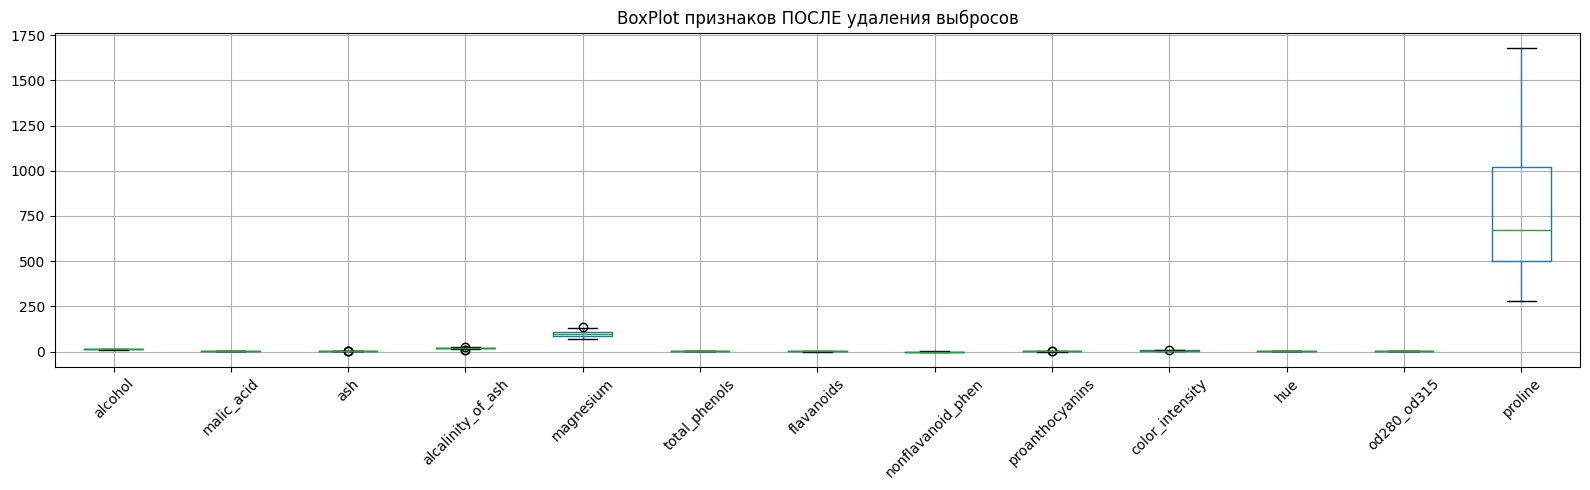

In [ ]:
feature_cols = [c for c in data.columns if c != 'class']

# BoxPlot ДО
plt.figure(figsize=(16, 5))
data[feature_cols].boxplot()
plt.title('BoxPlot признаков ДО удаления выбросов')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

def remove_outliers_iqr(df, cols):
    df_clean = df.copy()
    for col in cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df_clean = df_clean[
            (df_clean[col] >= lower) & (df_clean[col] <= upper)
        ]
    return df_clean

data = remove_outliers_iqr(data, feature_cols)
print(f"Размер после удаления выбросов: {data.shape}")

# BoxPlot ПОСЛЕ
plt.figure(figsize=(16, 5))
data[feature_cols].boxplot()
plt.title('BoxPlot признаков ПОСЛЕ удаления выбросов')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Проверка на пропущенные значения

In [ ]:
print("Пропущенные значения ДО заполнения:")
print(data.isnull().sum())

imputer = SimpleImputer(strategy='median')
data[feature_cols] = imputer.fit_transform(data[feature_cols])

print("\nПропущенные значения ПОСЛЕ заполнения:")
print(data.isnull().sum())

Пропущенные значения ДО заполнения:
class                0
alcohol              0
malic_acid           0
ash                  0
alcalinity_of_ash    0
magnesium            0
total_phenols        0
flavanoids           0
nonflavanoid_phen    0
proanthocyanins      0
color_intensity      0
hue                  0
od280_od315          0
proline              0
dtype: int64

Пропущенные значения ПОСЛЕ заполнения:
class                0
alcohol              0
malic_acid           0
ash                  0
alcalinity_of_ash    0
magnesium            0
total_phenols        0
flavanoids           0
nonflavanoid_phen    0
proanthocyanins      0
color_intensity      0
hue                  0
od280_od315          0
proline              0
dtype: int64


Масштабирование. Выбираем MinMaxScaler (нормализация [0, 1]):
 Признаки имеют разные единицы и диапазоны (proline ~0–1500, alcohol ~11–14).
 KNN использует расстояния → единый масштаб критически важен.
 MinMaxScaler сохраняет форму распределения и не чувствителен к нормальности.

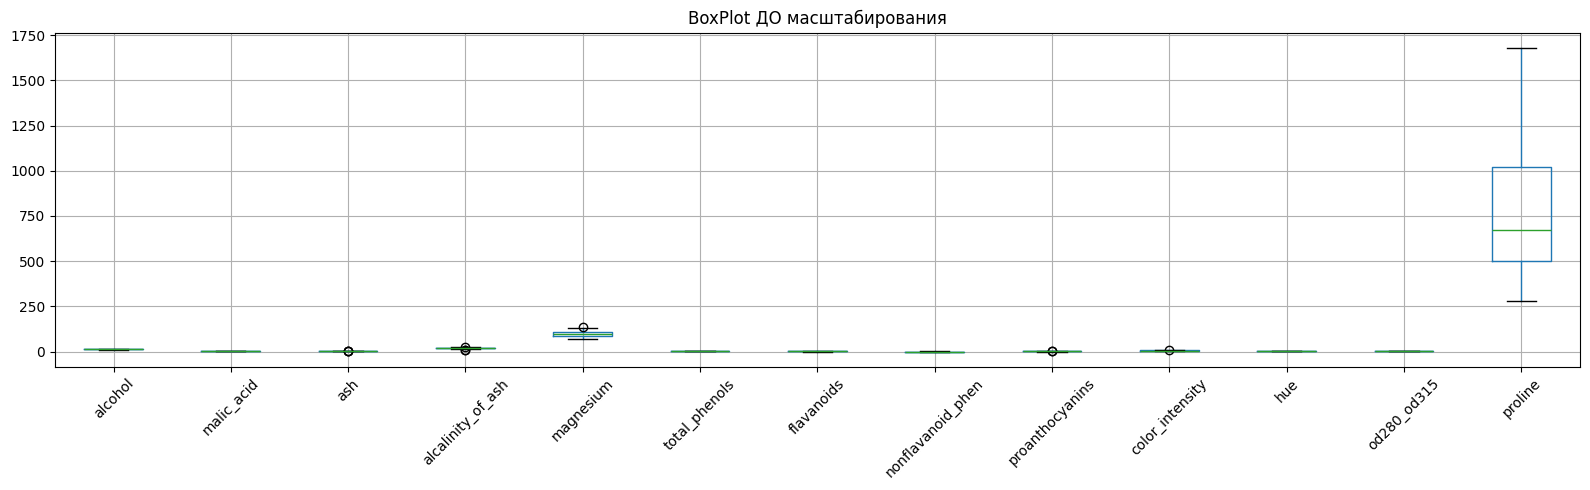

    alcohol  malic_acid       ash  alcalinity_of_ash  magnesium  \
0  0.824561    0.217978  0.598361           0.278481   0.890625   
1  0.523392    0.233708  0.360656           0.000000   0.468750   
2  0.511696    0.364045  0.795082           0.468354   0.484375   
3  0.865497    0.271910  0.655738           0.354430   0.671875   
4  0.535088    0.415730  0.959016           0.620253   0.750000   

   total_phenols  flavanoids  nonflavanoid_phen  proanthocyanins  \
0       0.627586    0.757660           0.283019            0.752   
1       0.575862    0.674095           0.245283            0.348   
2       0.627586    0.807799           0.320755            0.960   
3       0.989655    0.877437           0.207547            0.708   
4       0.627586    0.654596           0.490566            0.564   

   color_intensity       hue  od280_od315   proline  
0         0.463830  0.549451     0.970696  0.561341  
1         0.329787  0.560440     0.780220  0.550642  
2         0.468085  0.5384

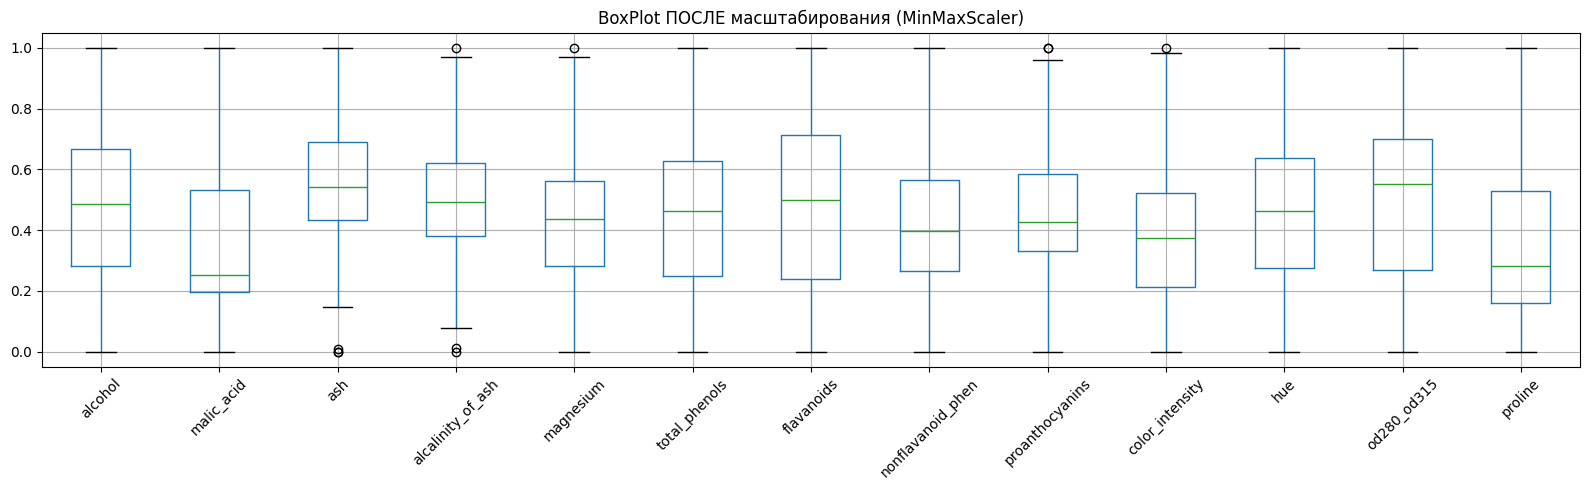

In [ ]:
plt.figure(figsize=(16, 5))
data[feature_cols].boxplot()
plt.title('BoxPlot ДО масштабирования')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

scaler = MinMaxScaler()
data[feature_cols] = scaler.fit_transform(data[feature_cols])

print(data[feature_cols].head())

plt.figure(figsize=(16, 5))
data[feature_cols].boxplot()
plt.title('BoxPlot ПОСЛЕ масштабирования (MinMaxScaler)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Все 13 признаков в датасете Wine — числовые (continuous).
# Категориальных столбцов нет → замена не требуется.
# Категориальных признаков нет. Все признаки числовые
Шаг замены категориальных признаков не применяется

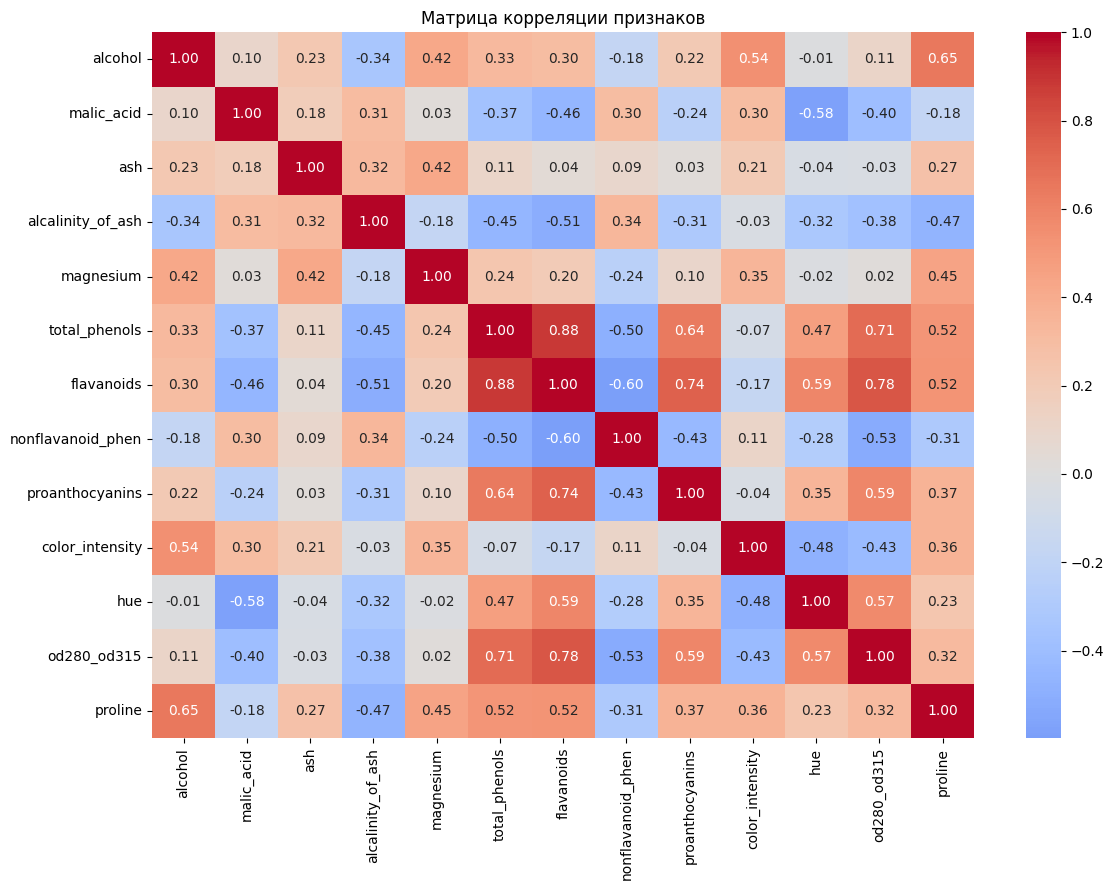

Количество сильных корреляций (|r| > 0.7) у каждого признака:
  flavanoids: 3
  total_phenols: 2
  od280_od315: 2
  proanthocyanins: 1
  alcohol: 0
  malic_acid: 0
  ash: 0
  alcalinity_of_ash: 0
  magnesium: 0
  nonflavanoid_phen: 0
  color_intensity: 0
  hue: 0
  proline: 0


In [ ]:
corr = data[feature_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Матрица корреляции признаков')
plt.tight_layout()
plt.show()

threshold = 0.7
high_corr_count = {}
for col in feature_cols:
    count = (corr[col].abs() > threshold).sum() - 1
    high_corr_count[col] = count

print("Количество сильных корреляций (|r| > 0.7) у каждого признака:")
for k, v in sorted(high_corr_count.items(), key=lambda x: -x[1]):
    print(f"  {k}: {v}")


# Вывод: наибольшее число высоких корреляций имеют признаки flavanoids, total_phenols, od280_od315.
Линейного классификатора в варианте 20 нет (классификаторы 1 и 4),
поэтому признаки с высокой корреляцией удалять не требуется.


In [ ]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(data['class'])  # 1→0, 2→1, 3→2

X = data[feature_cols].values
y = y_encoded

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# Бинаризация для OvR
y_train_bin = label_binarize(y_train, classes=[0, 1, 2])
y_test_bin  = label_binarize(y_test,  classes=[0, 1, 2])

Train: (128, 13), Test: (33, 13)


Лучшие параметры Decision Tree: {'estimator__criterion': 'gini', 'estimator__max_depth': 5, 'estimator__min_samples_split': 10}
Лучший Average Precision (CV): 0.8926

Матрица ошибок — Decision Tree (порог 0.5):
[[12  0  0]
 [ 3  9  0]
 [ 1  1  7]]

Точность модели:
  0.8485

Предсказание вероятностей — Decision Tree (первые 5 строк):
[[1.         0.         0.        ]
 [1.         0.         0.        ]
 [1.         0.         0.        ]
 [0.         1.         0.        ]
 [0.         0.33333333 0.        ]]

Матрица ошибок для класса 1 при пороге 0.0:
[[ 0 21]
 [ 0 12]]


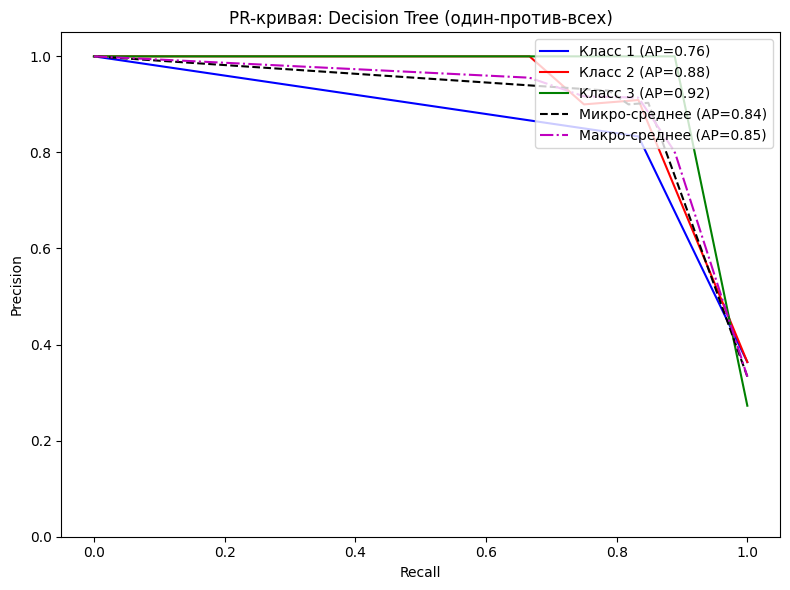

Класс 1: порог=1.0000 при Precision≈Recall≈0.8333
Класс 2: порог=0.3333 при Precision≈Recall≈0.9091
Класс 3: порог=1.0000 при Precision≈Recall≈1.0000


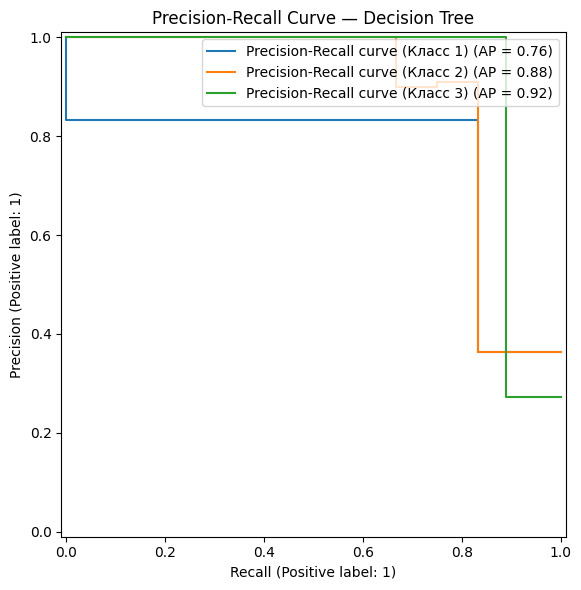

In [ ]:

param_grid_dt = {
    'estimator__max_depth':         [3, 5, 7, None],
    'estimator__min_samples_split': [2, 5, 10],
    'estimator__criterion':         ['gini', 'entropy']
}

dt_ovr = OneVsRestClassifier(DecisionTreeClassifier(random_state=42))

grid_dt = GridSearchCV(dt_ovr, param_grid_dt, cv=5,
                       scoring='average_precision', refit=True, n_jobs=-1)
grid_dt.fit(X_train, y_train_bin)

print("Лучшие параметры Decision Tree:", grid_dt.best_params_)
print("Лучший Average Precision (CV):", round(grid_dt.best_score_, 4))

best_dt = grid_dt.best_estimator_

# --- Матрица ошибок при пороге 0.5 ---
y_pred_dt = best_dt.predict(X_test)
print("\nМатрица ошибок — Decision Tree (порог 0.5):")
print(confusion_matrix(y_test_bin.argmax(axis=1), y_pred_dt.argmax(axis=1)))

print("\nТочность модели:")
print(f"  {(y_test_bin.argmax(axis=1) == y_pred_dt.argmax(axis=1)).mean():.4f}")

# --- Предсказание вероятностей (первые 5 строк) ---
y_proba_dt = best_dt.predict_proba(X_test)
print("\nПредсказание вероятностей — Decision Tree (первые 5 строк):")
print(y_proba_dt[:5])

# --- Матрица ошибок при пороге 0.0 ---
thr = 0.0
y_test_p = y_test_bin[:, 0].ravel()
y_pred_p = y_proba_dt[:, 0].ravel()
y_pred_thr = (y_pred_p >= thr).astype(int)
print(f"\nМатрица ошибок для класса 1 при пороге {thr}:")
print(confusion_matrix(y_test_p, y_pred_thr))

# --- Вычисление вероятности первого класса ---
y_t = best_dt.predict_proba(X_test)[:, 0]

# --- PR-кривая по классам ---
precision_dt, recall_dt, _ = precision_recall_curve(
    y_test_bin.ravel(), y_proba_dt.ravel())
ap_micro_dt = average_precision_score(y_test_bin, y_proba_dt, average='micro')
ap_macro_dt = average_precision_score(y_test_bin, y_proba_dt, average='macro')

aps_dt = []
plt.figure(figsize=(8, 6))
for i in range(3):
    prec_i, rec_i, _ = precision_recall_curve(y_test_bin[:, i], y_proba_dt[:, i])
    ap_i = average_precision_score(y_test_bin[:, i], y_proba_dt[:, i])
    aps_dt.append(ap_i)
    plt.plot(rec_i, prec_i, color=colors[i], label=f'{class_names[i]} (AP={ap_i:.2f})')

plt.plot(recall_dt, precision_dt, 'k--',
         label=f'Микро-среднее (AP={ap_micro_dt:.2f})')

all_rec = np.linspace(0, 1, 300)
mean_prec = np.zeros_like(all_rec)
for i in range(3):
    prec_i, rec_i, _ = precision_recall_curve(y_test_bin[:, i], y_proba_dt[:, i])
    mean_prec += np.interp(all_rec, rec_i[::-1], prec_i[::-1])
mean_prec /= 3
plt.plot(all_rec, mean_prec, 'm-.',
         label=f'Макро-среднее (AP={ap_macro_dt:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('PR-кривая: Decision Tree (один-против-всех)')
plt.legend(loc='upper right')
plt.ylim([0, 1.05])
plt.tight_layout()
plt.show()

# --- Поиск порога где Precision == Recall ---
for i in range(3):
    prec_i, rec_i, thr_i = precision_recall_curve(y_test_bin[:, i], y_proba_dt[:, i])
    diffs = abs(prec_i[:-1] - rec_i[:-1])
    idx = diffs.argmin()
    print(f"{class_names[i]}: порог={thr_i[idx]:.4f} при Precision≈Recall≈{prec_i[idx]:.4f}")

# --- PrecisionRecallDisplay ---
fig, ax = plt.subplots(figsize=(8, 6))
for i in range(3):
    PrecisionRecallDisplay.from_predictions(
        y_test_bin[:, i], y_proba_dt[:, i],
        name=f"Precision-Recall curve ({class_names[i]})",
        ax=ax
    )
ax.set_title("Precision-Recall Curve — Decision Tree")
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()


СРАВНЕНИЕ КЛАССИФИКАТОРОВ (площадь под PR-кривой)

KNN:
  Класс 1: AP = 1.000
  Класс 2: AP = 1.000
  Класс 3: AP = 1.000
  Микро-AP: 1.000  |  Макро-AP: 1.000

Decision Tree:
  Класс 1: AP = 0.755
  Класс 2: AP = 0.878
  Класс 3: AP = 0.919
  Микро-AP: 0.837  |  Макро-AP: 0.851


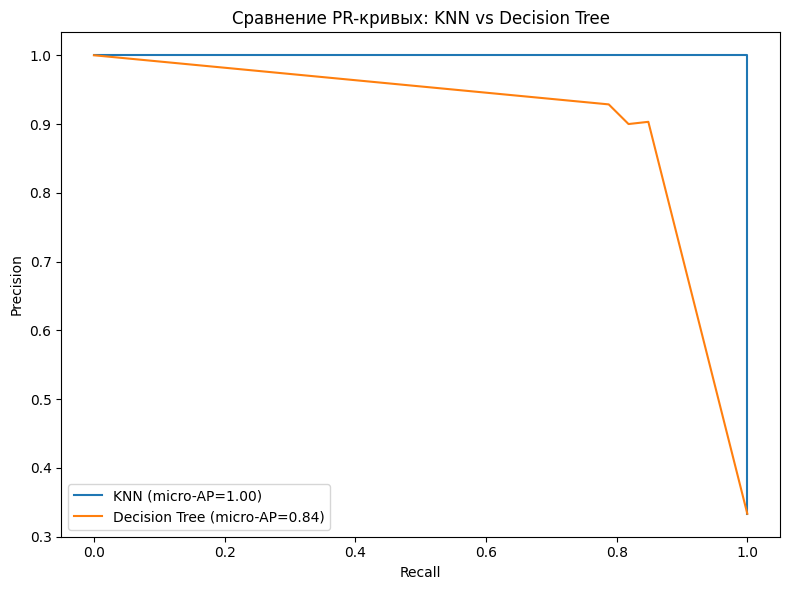


Выводы:
- Лучший классификатор по micro-AP — KNN.
- KNN чувствителен к масштабу признаков (MinMaxScaler обязателен),
  хорошо работает при чётких кластерах в данных.
- Decision Tree интерпретируем и не требует масштабирования,
  но склонен к переобучению при больших глубинах (ограничиваем max_depth).
- Average Precision (площадь под PR-кривой) — основная метрика сравнения,
  так как классы несбалансированы (класс 3 меньше остальных).
- Чем выше AP — тем лучше классификатор справляется с распознаванием
  каждого класса при разных порогах принятия решения.



In [ ]:
print("=" * 55)
print("СРАВНЕНИЕ КЛАССИФИКАТОРОВ (площадь под PR-кривой)")
print("=" * 55)

print(f"\nKNN:")
for i, name in enumerate(class_names):
    print(f"  {name}: AP = {aps_knn[i]:.3f}")
print(f"  Микро-AP: {ap_micro_knn:.3f}  |  Макро-AP: {ap_macro_knn:.3f}")

print(f"\nDecision Tree:")
for i, name in enumerate(class_names):
    print(f"  {name}: AP = {aps_dt[i]:.3f}")
print(f"  Микро-AP: {ap_micro_dt:.3f}  |  Макро-AP: {ap_macro_dt:.3f}")

# Сравнительный график
plt.figure(figsize=(8, 6))
plt.plot(recall_knn, precision_knn, label=f'KNN (micro-AP={ap_micro_knn:.2f})')
plt.plot(recall_dt,  precision_dt,  label=f'Decision Tree (micro-AP={ap_micro_dt:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Сравнение PR-кривых: KNN vs Decision Tree')
plt.legend()
plt.tight_layout()
plt.show()

winner = 'KNN' if ap_micro_knn > ap_micro_dt else 'Decision Tree'
print(f"""
Выводы:
- Лучший классификатор по micro-AP — {winner}.
- KNN чувствителен к масштабу признаков (MinMaxScaler обязателен),
  хорошо работает при чётких кластерах в данных.
- Decision Tree интерпретируем и не требует масштабирования,
  но склонен к переобучению при больших глубинах (ограничиваем max_depth).
- Average Precision (площадь под PR-кривой) — основная метрика сравнения,
  так как классы несбалансированы (класс 3 меньше остальных).
- Чем выше AP — тем лучше классификатор справляется с распознаванием
  каждого класса при разных порогах принятия решения.
""")